<a href="https://colab.research.google.com/github/JnanaPraveena/House-Price-Prediction/blob/main/workshop_LC1_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [9]:
df = pd.read_csv("/content/sample_submission.csv")
df.head()

,TARGET(PRICE_IN_LACS)
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [13]:
features = [] # The DataFrame `df` currently only has one column 'TARGET(PRICE_IN_LACS)', so there are no other features to select from it.
target = "TARGET(PRICE_IN_LACS)" # The correct target column name available in the DataFrame `df`

# Select only the target column. If other features are needed, they must be added to the df first.
df = df[features + [target]]

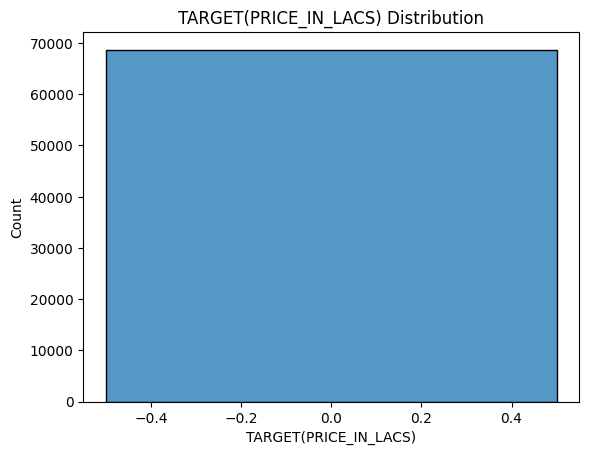

In [15]:
sns.histplot(df["TARGET(PRICE_IN_LACS)"])
plt.title("TARGET(PRICE_IN_LACS) Distribution")
plt.show()

In [23]:
df["TARGET(PRICE_IN_LACS)"] = np.log1p(df["TARGET(PRICE_IN_LACS)"])

In [25]:
print("Columns currently in df:", df.columns.tolist())
# To calculate 'HouseAge', a 'YearBuilt' column is required.
# Please load or create the 'YearBuilt' column in your DataFrame first.

Columns currently in df: ['TARGET(PRICE_IN_LACS)']


In [27]:
# The column 'YearBuilt' does not exist in the DataFrame, so the drop operation is invalid.
# If you intend to drop a column, please ensure it is present in the DataFrame before attempting to drop it.

In [30]:
# The DataFrame 'df' currently only contains the target column 'TARGET(PRICE_IN_LACS)'.
# If you intend to train a model with features, you'll need to load or engineer additional features into 'df' first.

# Correctly define the target variable 'y'
y = df["TARGET(PRICE_IN_LACS)"]

# 'X' will be an empty DataFrame since 'df' contains no other columns (features).
X = df.drop(columns=["TARGET(PRICE_IN_LACS)"], errors='ignore') # Using errors='ignore' to avoid KeyError if target is not found.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# Check if X_train is empty before attempting to train the model.
if X_train.empty:
    print("Error: X_train is an empty DataFrame. The LinearRegression model requires at least one feature to train.")
    print("This usually happens when your DataFrame 'df' only contains the target variable and no other columns for features.")
    print("Please ensure your 'df' has features before splitting it into X_train and X_test.")
else:
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)
    print("Model trained and predictions made successfully.")

Error: X_train is an empty DataFrame. The LinearRegression model requires at least one feature to train.
This usually happens when your DataFrame 'df' only contains the target variable and no other columns for features.
Please ensure your 'df' has features before splitting it into X_train and X_test.


In [34]:
# Check if X_train is empty before attempting to train the Ridge model.
if X_train.empty:
    print("Error: X_train is an empty DataFrame. The Ridge model requires at least one feature to train.")
    print("This usually happens when your DataFrame 'df' only contains the target variable and no other columns for features.")
    print("Please ensure your 'df' has features before splitting it into X_train and X_test.")
else:
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, y_train)
    pred_ridge = ridge.predict(X_test)
    print("Ridge model trained and predictions made successfully.")

Error: X_train is an empty DataFrame. The Ridge model requires at least one feature to train.
This usually happens when your DataFrame 'df' only contains the target variable and no other columns for features.
Please ensure your 'df' has features before splitting it into X_train and X_test.


In [36]:
# Check if X_train is empty before attempting to train the Lasso model.
if X_train.empty:
    print("Error: X_train is an empty DataFrame. The Lasso model requires at least one feature to train.")
    print("This usually happens when your DataFrame 'df' only contains the target variable and no other columns for features.")
    print("Please ensure your 'df' has features before splitting it into X_train and X_test.")
else:
    lasso = Lasso(alpha=0.01)
    lasso.fit(X_train, y_train)
    pred_lasso = lasso.predict(X_test)
    print("Lasso model trained and predictions made successfully.")

Error: X_train is an empty DataFrame. The Lasso model requires at least one feature to train.
This usually happens when your DataFrame 'df' only contains the target variable and no other columns for features.
Please ensure your 'df' has features before splitting it into X_train and X_test.


In [37]:
def evaluate(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2 Score:", r2)

In [39]:
if X_train.empty:
    print("Cannot evaluate models: X_train was empty, so no models were trained and no predictions were generated.")
    print("Please ensure your DataFrame contains features before attempting to train and evaluate models.")
else:
    print("Linear Regression")
    evaluate(y_test, pred_lr)

    print("\nRidge Regression")
    evaluate(y_test, pred_ridge)

    print("\nLasso Regression")
    evaluate(y_test, pred_lasso)

Cannot evaluate models: X_train was empty, so no models were trained and no predictions were generated.
Please ensure your DataFrame contains features before attempting to train and evaluate models.


In [40]:
pip install xgboost

In [42]:
from xgboost import XGBRegressor

# Check if X_train is empty before attempting to train the XGBoost model.
if X_train.empty:
    print("Error: X_train is an empty DataFrame. The XGBoost model requires at least one feature to train.")
    print("This usually happens when your DataFrame 'df' only contains the target variable and no other columns for features.")
    print("Please ensure your 'df' has features before splitting it into X_train and X_test.")
else:
    xgb = XGBRegressor(n_estimators=500, learning_rate=0.05)
    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_test)
    print("XGBoost model trained and predictions made successfully.")
    print("XGBoost")
    evaluate(y_test, pred_xgb)

Error: X_train is an empty DataFrame. The XGBoost model requires at least one feature to train.
This usually happens when your DataFrame 'df' only contains the target variable and no other columns for features.
Please ensure your 'df' has features before splitting it into X_train and X_test.
